In [2]:
##load packages
##Set path
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from scipy.spatial.distance import pdist, squareform
from nilearn.image import resample_to_img


base_dir = Path(r"D:\NTU_PSY\Documents\Patric_Asen_BrainHackProject")



##讀取特定subject的特定concepts trial index

def load_and_filter_conditions(
    base_dir,
    sub_id,
    targets,
    filename="subject_fMRI_nii/sub-01_condition_with_ratings.csv",
    verbose=True
):
    """
    Load + filter + sort fMRI condition table
    """

    # -------------------------
    # 1. load data
    # -------------------------
    path = base_dir / filename.replace("sub-01", sub_id)
    df = pd.read_csv(path)

    # -------------------------
    # 2. filter concepts
    # -------------------------
    df_selected = df[df["concept"].isin(targets)].copy()

    # -------------------------
    # 3. ordering
    # -------------------------
    df_selected["concept"] = pd.Categorical(
        df_selected["concept"],
        categories=targets,
        ordered=True
    )

    df_selected = (
        df_selected
        .sort_values(by=["concept"])
        .reset_index(drop=True)
    )

    # -------------------------
    # 4. print (optional)
    # -------------------------
    if verbose:
        print(f"\n[{sub_id}] total selected:", len(df_selected))
        print(df_selected["concept"].value_counts())
        print(df_selected)

    return df_selected



##由篩選過的trial index讀取部分concepts的fMRI trial

def extract_fmri_volumes_rowwise(
    df_sorted,
    base_dir,
    sub_id="sub-01",
    verbose=True
):
    """
    Extract fMRI volumes strictly following df row order.

    Returns
    -------
    selected_volumes : np.ndarray
        shape = (x, y, z, n_trials)
    """

    selected_volumes = []

    for row in df_sorted.itertuples():

        img_path = (
            base_dir /
            "subject_fMRI_nii" /
            sub_id /
            row.session /
            f"{sub_id}_{row.session}_run-{row.run:02d}_betas.nii"
        )

        img = nib.load(img_path)
        data = img.get_fdata()

        t = int(row.trial_idx)
        vol = data[..., t]

        selected_volumes.append(vol)

    selected_volumes = np.stack(selected_volumes, axis=-1)

    if verbose:
        print("Final shape:", selected_volumes.shape)
        print("mean:", np.mean(selected_volumes))
        print("std:", np.std(selected_volumes))
        print("min:", np.min(selected_volumes))
        print("max:", np.max(selected_volumes))

    return selected_volumes




##讀取並轉換atlas

reference_img = nib.load(base_dir / "subject_fMRI_nii\sub-01\ses-things01\sub-01_ses-things01_run-01_betas.nii")

atlas_img = nib.load(base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz")
atlas = nib.load(base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz").get_fdata()
print(atlas.shape)
print(atlas_img.affine)

##對atlas進行線性轉換，符合fMRI結構
print("beta shape:\n", reference_img.shape)
print("atlas shape:\n", atlas_img.shape)

print("beta affine:\n", reference_img.affine)
print("atlas affine:\n", atlas_img.affine)


atlas_rs = resample_to_img(atlas_img, reference_img, interpolation="nearest")
atlas = atlas_rs.get_fdata()

print("===resampled atlas info===")
print("resampled atlas shape:\n", atlas_rs.shape)
print("resampled atlas affine:\n", atlas_rs.affine)

##讀取atlas region名稱
tree = ET.parse(base_dir / "HCP_atlas\HCP-Multi-Modal-Parcellation-1.0.xml")
root = tree.getroot()

labels = {}

for label in root.find("data").findall("label"):
    idx = int(label.attrib["index"])
    name = label.text.strip()
    if name != "*.*.*.*.*":
        labels[idx] = name

print(labels)

df_labels = pd.DataFrame.from_dict(
    labels,
    orient="index",
    columns=["name"]
).reset_index().rename(columns={"index": "roi_id"})

def parse_name(name):
    try:
        hemi, region = name.split("_", 1)
        return hemi, region
    except:
        return None, name

df_labels[["hemi", "region"]] = df_labels["name"].apply(
    lambda x: pd.Series(parse_name(x))
)
print(df_labels.head())



##找尋特定roi id
def search_roi(df_labels, keyword):
    result = df_labels[
        df_labels["name"].str.contains(keyword, case=False, na=False)
    ].copy()

    return result.sort_values("roi_id")



##由已有的fMRI影像繪製特定roi的RDM

def compute_roi_rdm(
    atlas,
    selected_volumes,
    roi_ids,
    title="ROI RDM",
    metric="correlation",
    plot=True
):
    """
    atlas: 3D label map (x,y,z)
    selected_volumes: 4D (x,y,z,n_trials)
    roi_ids: list of ROI indices
    """

    # -------------------------
    # 1. ROI mask
    # -------------------------
    roi_mask = np.isin(atlas, roi_ids)

    print("ROI voxel count:", np.sum(roi_mask))

    # -------------------------
    # 2. extract voxel x trials
    # -------------------------
    roi_data = selected_volumes[roi_mask]

    print("ROI data shape (voxels, trials):", roi_data.shape)

    # safety check
    if roi_data.shape[0] == 0:
        raise ValueError("ROI mask is empty. Check roi_ids.")

    # -------------------------
    # 3. reshape for RSA
    # -------------------------
    trial_pattern = roi_data.T  # (trials, voxels)

    # -------------------------
    # 4. compute RDM
    # -------------------------
    brain_rdm = squareform(
        pdist(trial_pattern, metric=metric)
    )

    print("RDM shape:", brain_rdm.shape)

    # -------------------------
    # 5. plot
    # -------------------------
    if plot:
        fig, ax = plt.subplots(figsize=(8, 8))

        im = ax.imshow(brain_rdm, interpolation="none")

        ax.set_title(title)
        plt.colorbar(im, ax=ax, label="distance")

        plt.tight_layout()
        plt.show()

    return roi_mask, roi_data, brain_rdm

(256, 256, 256)
[[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
beta shape:
 (72, 91, 75, 92)
atlas shape:
 (256, 256, 256)
beta affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
atlas affine:
 [[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
===resampled atlas info===
resampled atlas shape:
 (72, 91, 75)
resampled atlas affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
{1: 'L_V1', 2: 'L_MST', 3: 'L_V6', 4: 'L_V2', 5: 'L_V3', 6: 'L_V4', 7: 'L_V8', 8: 'L_4', 9: 'L_3b', 10: 'L_FEF', 11: 'L_PEF', 12: 'L_55b', 13: 'L_

How to generate RDM

In [5]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


In [39]:
import numpy as np

grasp_volumes = np.load(
    base_dir / "processed_data" / "sub-01_grasp_volumes.npy"
)

hold_volumes = np.load(
    base_dir / "processed_data" / "sub-01_hold_volumes.npy"
)

In [40]:
AIP_ids = [
    117, 1117
]

ROI voxel count: 570
ROI data shape (voxels, trials): (570, 720)
RDM shape: (720, 720)


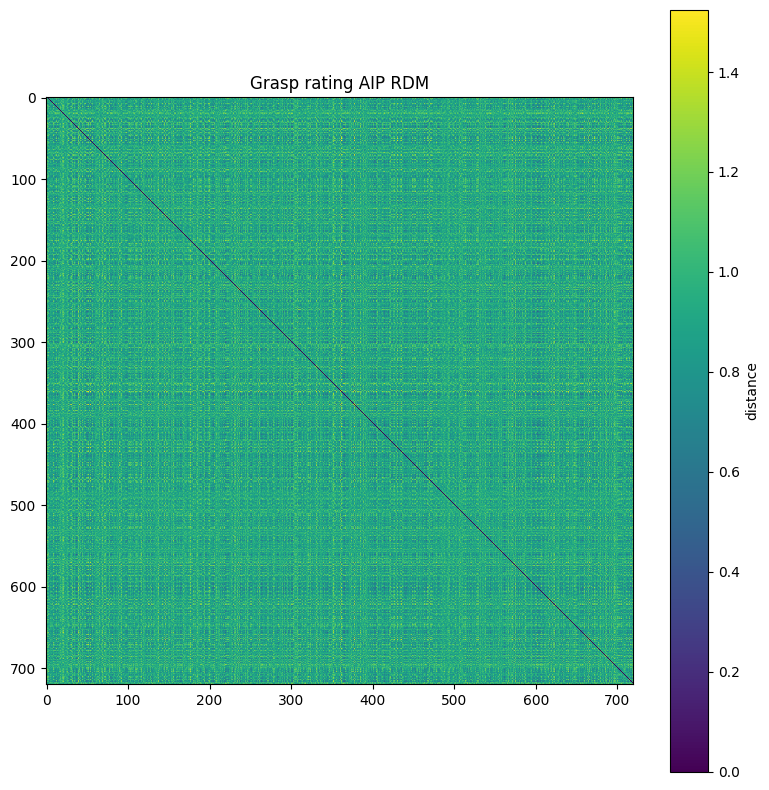

In [41]:
AIP_mask, AIP_data, AIP_RDM_grasp = compute_roi_rdm(
    atlas,
    grasp_volumes,
    AIP_ids,
    title="Grasp rating AIP RDM",
    metric="correlation",
    plot=True
)

ROI voxel count: 570
ROI data shape (voxels, trials): (570, 720)
RDM shape: (720, 720)


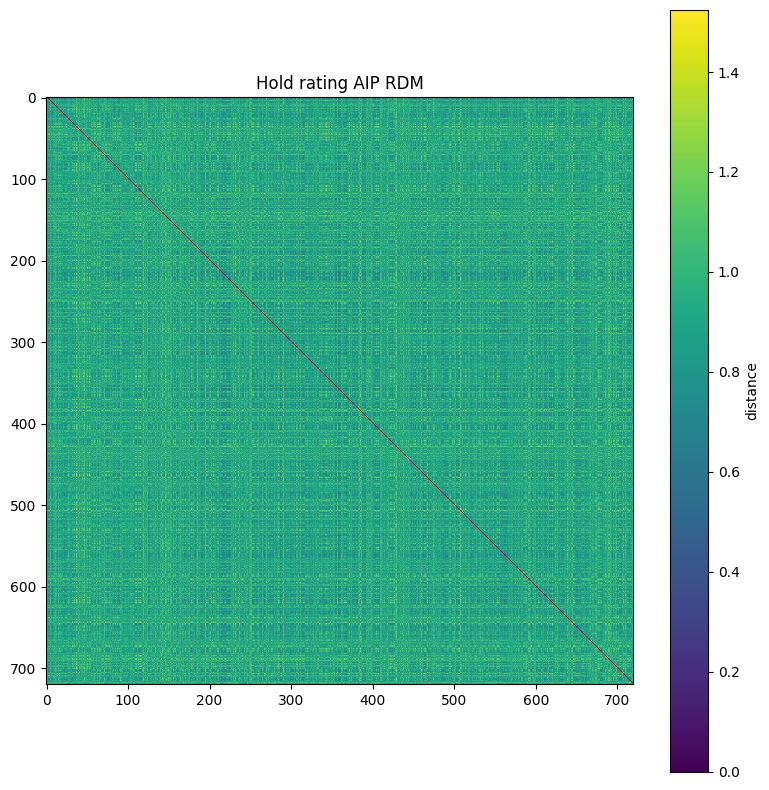

In [42]:
AIP_mask, AIP_data, AIP_RDM_hold = compute_roi_rdm(
    atlas,
    hold_volumes,
    AIP_ids,
    title="Hold rating AIP RDM",
    metric="correlation",
    plot=True
)

In [21]:
grasp_rating = pd.read_csv(base_dir / "behavior data\concepts_sorted_by_grasp.csv")
hold_rating = pd.read_csv(base_dir / "behavior data\concepts_sorted_by_hold.csv")

print(grasp_rating.shape)
print(hold_rating)

(720, 3)
              concept  grasp_rating  hold_rating
0               spoon        6.8378       6.8919
1                comb        6.7500       6.8889
2           candy_bar        6.7692       6.8718
3              peanut        6.7179       6.8718
4          shower_cap        6.6053       6.8684
..                ...           ...          ...
715          elephant        1.8649       1.2432
716       steamroller        2.4872       1.2308
717        rhinoceros        2.0000       1.2000
718  aircraft_carrier        2.0833       1.1944
719     space_shuttle        1.8421       1.1842

[720 rows x 3 columns]


In [19]:
from scipy.spatial.distance import pdist, squareform

grasp_values = (
    grasp_rating["grasp_rating"]
    .values
    .reshape(-1, 1)
)

grasp_rdm = squareform(
    pdist(
        grasp_values,
        metric="euclidean"
    )
)

print(grasp_rdm.shape)

(720, 720)


In [22]:
hold_values = (
    hold_rating["hold_rating"]
    .values
    .reshape(-1, 1)
)

hold_rdm = squareform(
    pdist(
        hold_values,
        metric="euclidean"
    )
)

print(hold_rdm.shape)

(720, 720)


In [26]:
features = grasp_rating[
    ["grasp_rating",
     "hold_rating"]
].values

grasp_hold_rdm = squareform(
    pdist(
        features,
        metric="euclidean"
    )
)

print(grasp_hold_rdm.shape)

(720, 720)


In [32]:
behavior_rdms = {
    "grasp": grasp_rdm,
    "hold": hold_rdm,
    "grasp_hold": grasp_hold_rdm
}

np.savez(
    base_dir / "behavior data" / "behavior_rdms.npz",
    grasp=grasp_rdm,
    hold=hold_rdm,
    grasp_hold=grasp_hold_rdm
)

In [34]:
data = np.load(base_dir / "behavior data" / "behavior_rdms.npz")

grasp_rdm = data["grasp"]
hold_rdm = data["hold"]
grasp_hold_rdm = data["grasp_hold"]

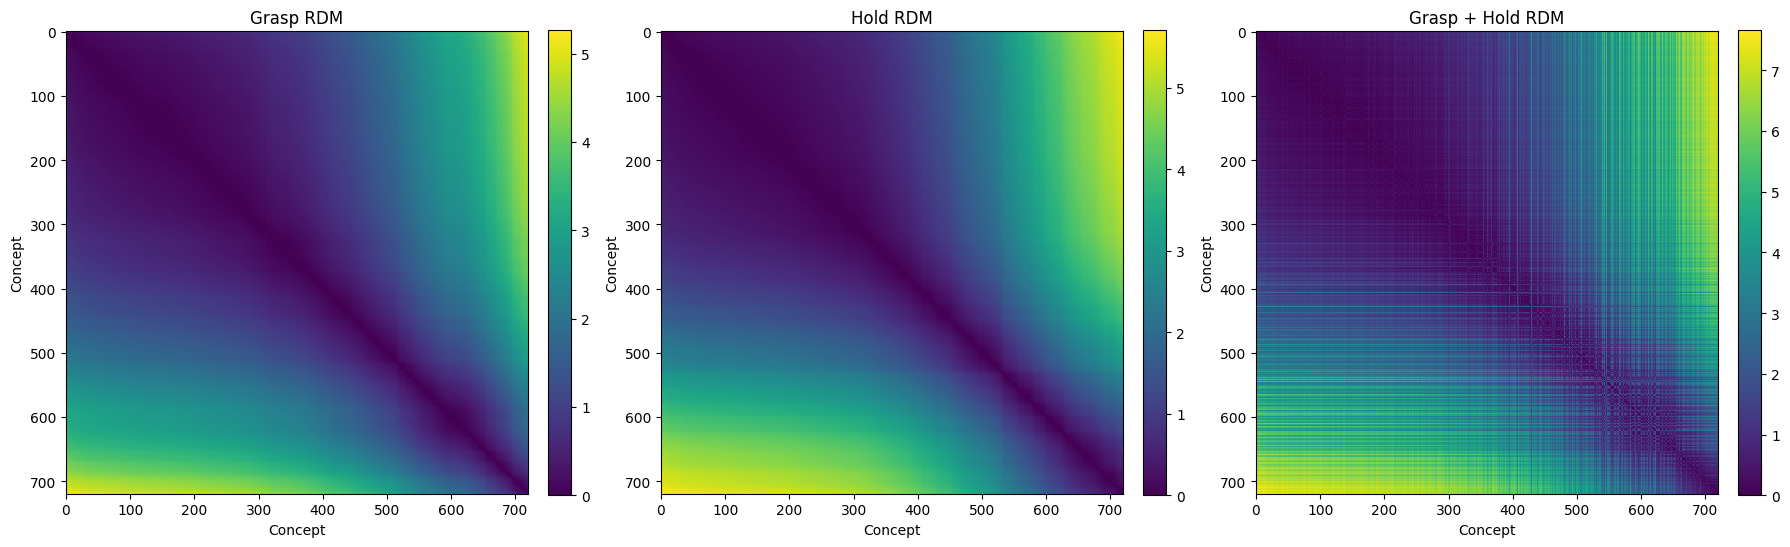

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grasp RDM ---
im0 = axes[0].imshow(grasp_rdm, interpolation="none")
axes[0].set_title("Grasp RDM")
axes[0].set_xlabel("Concept")
axes[0].set_ylabel("Concept")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Hold RDM ---
im1 = axes[1].imshow(hold_rdm, interpolation="none")
axes[1].set_title("Hold RDM")
axes[1].set_xlabel("Concept")
axes[1].set_ylabel("Concept")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Grasp + Hold RDM ---
im2 = axes[2].imshow(grasp_hold_rdm, interpolation="none")
axes[2].set_title("Grasp + Hold RDM")
axes[2].set_xlabel("Concept")
axes[2].set_ylabel("Concept")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

plt.show()

# RSA

In [49]:
from scipy.spatial.distance import squareform
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def vec(rdm):
    return squareform(rdm)

In [54]:
aip_grasp_vec = vec(AIP_RDM_grasp)
grasp_vec = vec(grasp_rdm)

spearman_corr, spearman_p = stats.spearmanr(aip_grasp_vec, grasp_vec)
pearson_corr, pearson_p = stats.pearsonr(aip_grasp_vec, grasp_vec)

print("\n===== AIP vs Grasp RSA =====")
print(f"Spearman rho: {spearman_corr:.4f}, p: {spearman_p:.4g}")
print(f"Pearson r   : {pearson_corr:.4f}, p: {pearson_p:.4g}")


===== AIP vs Grasp RSA =====
Spearman rho: 0.0063, p: 0.001384
Pearson r   : 0.0115, p: 4.858e-09


In [51]:
aip_hold_vec = vec(AIP_RDM_hold)
hold_vec = vec(hold_rdm)

spearman_corr, spearman_p = stats.spearmanr(aip_hold_vec, hold_vec)
pearson_corr, pearson_p = stats.pearsonr(aip_hold_vec, hold_vec)

print("\n===== AIP vs Hold RSA =====")
print(f"Spearman rho: {spearman_corr:.4f}, p: {spearman_p:.4g}")
print(f"Pearson r   : {pearson_corr:.4f}, p: {pearson_p:.4g}")


===== AIP vs Hold RSA =====
Spearman rho: 0.0052, p: 0.008343
Pearson r   : 0.0104, p: 1.074e-07


In [55]:
mix_vec = vec(grasp_hold_rdm)

spearman_corr, spearman_p = stats.spearmanr(aip_grasp_vec, mix_vec)
pearson_corr, pearson_p = stats.pearsonr(aip_grasp_vec, mix_vec)

print("\n===== AIP vs Grasp+Hold RSA =====")
print(f"Spearman rho: {spearman_corr:.4f}, p: {spearman_p:.4g}")
print(f"Pearson r   : {pearson_corr:.4f}, p: {pearson_p:.4g}")


===== AIP vs Grasp+Hold RSA =====
Spearman rho: 0.0056, p: 0.004266
Pearson r   : 0.0112, p: 1.051e-08


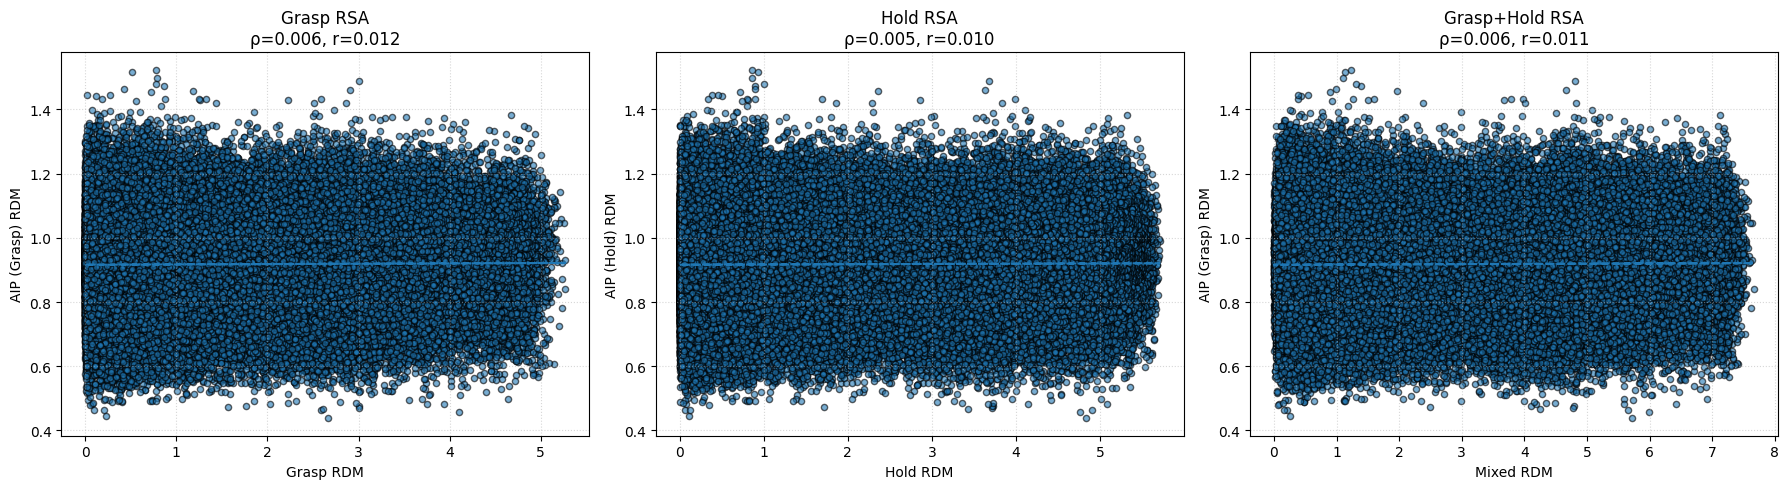

In [57]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
import scipy.stats as stats

# -------------------------
# flatten function
# -------------------------
def vec(rdm):
    return squareform(rdm)

# -------------------------
# vectors
# -------------------------
aip_grasp_vec = vec(AIP_RDM_grasp)
grasp_vec = vec(grasp_rdm)

aip_hold_vec = vec(AIP_RDM_hold)
hold_vec = vec(hold_rdm)

mix_vec = vec(grasp_hold_rdm)

# -------------------------
# figure
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. Grasp RSA
# =========================
axes[0].scatter(
    grasp_vec,
    aip_grasp_vec,
    alpha=0.6,
    edgecolors='k',
    s=20
)

m, b = np.polyfit(grasp_vec, aip_grasp_vec, 1)
axes[0].plot(grasp_vec, m * grasp_vec + b, linestyle='--')

rho, p = stats.spearmanr(grasp_vec, aip_grasp_vec)
r, p2 = stats.pearsonr(grasp_vec, aip_grasp_vec)

axes[0].set_title(f"Grasp RSA\nρ={rho:.3f}, r={r:.3f}")
axes[0].set_xlabel("Grasp RDM")
axes[0].set_ylabel("AIP (Grasp) RDM")
axes[0].grid(True, linestyle=":", alpha=0.5)

# =========================
# 2. Hold RSA
# =========================
axes[1].scatter(
    hold_vec,
    aip_hold_vec,
    alpha=0.6,
    edgecolors='k',
    s=20
)

m, b = np.polyfit(hold_vec, aip_hold_vec, 1)
axes[1].plot(hold_vec, m * hold_vec + b, linestyle='--')

rho, p = stats.spearmanr(hold_vec, aip_hold_vec)
r, p2 = stats.pearsonr(hold_vec, aip_hold_vec)

axes[1].set_title(f"Hold RSA\nρ={rho:.3f}, r={r:.3f}")
axes[1].set_xlabel("Hold RDM")
axes[1].set_ylabel("AIP (Hold) RDM")
axes[1].grid(True, linestyle=":", alpha=0.5)

# =========================
# 3. Mix RSA
# =========================
axes[2].scatter(
    mix_vec,
    aip_grasp_vec,
    alpha=0.6,
    edgecolors='k',
    s=20
)

m, b = np.polyfit(mix_vec, aip_grasp_vec, 1)
axes[2].plot(mix_vec, m * mix_vec + b, linestyle='--')

rho, p = stats.spearmanr(mix_vec, aip_grasp_vec)
r, p2 = stats.pearsonr(mix_vec, aip_grasp_vec)

axes[2].set_title(f"Grasp+Hold RSA\nρ={rho:.3f}, r={r:.3f}")
axes[2].set_xlabel("Mixed RDM")
axes[2].set_ylabel("AIP (Grasp) RDM")
axes[2].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

Hypothesis 1：weak affordance encoding

AIP 有 encoding，但非常 distributed / weak

Hypothesis 2：model RDM 太 simple

你現在 model 是：

absolute difference of ratings

👉 這通常只 capture very coarse structure

Hypothesis 3：brain RDM noise-dominated

常見於：

single-subject RSA
unsmoothed trial-wise beta